# Test task for RWB Data Science Intern position

Перед запуском нужно разархивировать best-checkpoint.zip в папку, в которой запускается этот ноутбук.

## Устанавливаем нужные библиотеки

In [1]:
# import sys

# !{sys.executable} -m pip install -Uq anthropic spacy pymorphy3 scikit-learn sentence_transformers umap-learn plotly kaleido openai more-itertools datasets

## Импорты

In [2]:
import re
import os
import asyncio
import string
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import warnings
from copy import deepcopy

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import pymorphy3
import spacy
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import HDBSCAN
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import(
    f1_score, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    confusion_matrix, 
    classification_report,
    make_scorer,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


from sentence_transformers import SentenceTransformer
from sentence_transformers import util

import umap
# import plotly.express as px

from pydantic import BaseModel
from typing import Literal, Optional
from more_itertools import chunked
# from openai import AsyncOpenAI
import anthropic
from anthropic.types.messages.batch_create_params import Request
from IPython.display import clear_output

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments

# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')
# nltk.download('wordnet')

## Загружаем изначальные данные

In [3]:
df = pd.read_csv("data.csv")
# df.head(20)

In [4]:
df.head(10)
# df.tail(10)

,query_text
0,гетры y2k черные широкие
1,шторы в спальню 100*210
2,big bcaa
3,щетки на болгарку диолд
4,цинк и медь хелат
5,кресло мягкое с высокой спинкой
6,диван раскладной денвер
7,кроссовки 12 см
8,иглы 30g 12 мм
9,жалюзи день ночь 140 ширина


## EDA

### Посмотрим сначала на базовые статистики

#### Длина queries

Смотрим на распределение длин запросов.

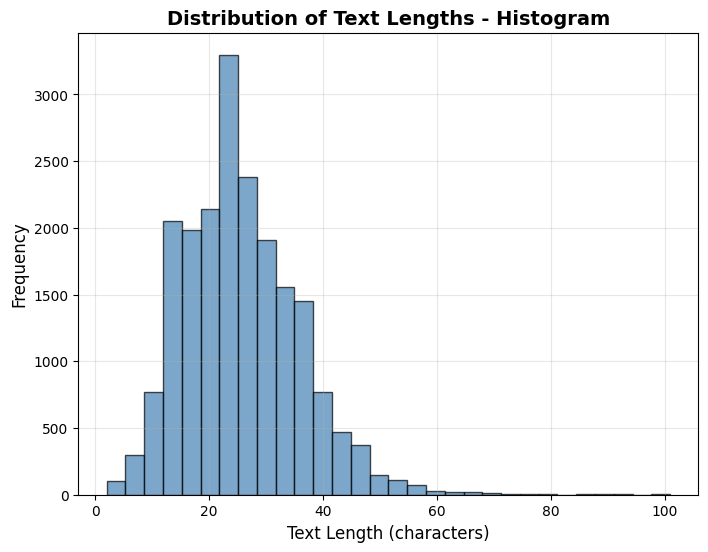

In [5]:
lengths_series = df["query_text"].apply(lambda x: len(x))
# lengths_series

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(lengths_series, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Text Length (characters)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Text Lengths - Histogram', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

In [6]:
print(f"Средняя длина запроса в символах: {lengths_series.mean()}")
print(f"Медианная длина запроса в символах: {lengths_series.median()}")

Средняя длина запроса в символах: 25.56565
Медианная длина запроса в символах: 25.0


Большинство запросов по длине похожи на эти:

In [7]:
df[lengths_series == 25]["query_text"].head(5)

23     корпус для колонок в авто
55     шапочка кондитера сеточка
110    вкладыши для зимних сапог
132    футболка с тигром женская
133    шнурки резинки фиолетовые
Name: query_text, dtype: str

#### Распределение по языку

Посмотрим на распределение по языку - только символы русского языка, английский и смешанный формат.

In [8]:
def detect_language(text: str) -> str:
    if not isinstance(text, str):
        raise TypeError("text variable should be string!")
    
    has_cyrillic = bool(re.search(r'[а-яё]', text.lower()))
    has_latin = bool(re.search(r'[a-z]', text.lower()))
    
    if has_cyrillic and not has_latin:
        return 'russian'
    elif has_latin and not has_cyrillic:
        return 'english'
    elif has_cyrillic and has_latin:
        return 'mixed'
    else:
        return 'unknown'

In [9]:
queries_texts = df["query_text"].apply(lambda x: detect_language(x))

In [10]:
queries_texts.value_counts()

query_text
russian    15712
mixed       3282
english     1002
unknown        4
Name: count, dtype: int64

Большая часть запросов исключительно состоит из russian и mixed текстов. И только чуть больше 1000 из исключительно английских текстов.

In [11]:
# df[queries_texts == "english"]["query_text"]

Есть также запросы, в которых нет слов и они являются просто числами - 4 таких запроса.

In [12]:
df[queries_texts == "unknown"]["query_text"]

3188        664
16210       067
17557      2450
17960    150 70
Name: query_text, dtype: str

#### Доля запросов с числами

In [13]:
has_number = df["query_text"].apply(lambda x: any(char.isdigit() for char in x))
has_number.value_counts()

query_text
False    14908
True      5092
Name: count, dtype: int64

2/3 запросов без чисел.

#### Доля запросов с пунктуацией

In [14]:
has_punctuation = df["query_text"].apply(lambda x: any(char in string.punctuation for char in x))
has_punctuation.value_counts()

query_text
False    19414
True       586
Name: count, dtype: int64

Очень мало запросов с пунктуацией

In [15]:
# duplicates = df.duplicated(subset=["query_text"])
# duplicates.sum()
# Нет дубликатов

### Токенизация, лемматизация, поиск самых важных токенов

Для лемматизации

In [16]:
morph = pymorphy3.MorphAnalyzer()
wnl_en = WordNetLemmatizer()

In [17]:
russian_stopwords = set(stopwords.words("russian"))
english_stopwords = set(stopwords.words("english"))
                
def tokenize_or_lemmatize(text: str, return_lemmas: bool = False) -> list:
    text = text.lower().strip()

    text = text.replace("ё", "e")

    text = re.sub(r'[^a-zA-Zа-яА-ЯёЁ]+', ' ', text)
    # text = re.sub(r'[^a-zA-Zа-яА-ЯёЁ0-9]+', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    tokens = word_tokenize(text, language="russian")

    filtered_tokens = []

    for tok in tokens:
        if (tok in russian_stopwords) or (tok in english_stopwords):
            continue

        filtered_tokens.append(tok)

    if return_lemmas:
        lemmas = []
        for tok in filtered_tokens:
            if re.search(r'[а-я]', tok):  
                lemmas.append(morph.parse(tok)[0].normal_form)
            else:  
                lemmas.append(wnl_en.lemmatize(tok))  # english words
        
        return lemmas
    else:
        return filtered_tokens

In [18]:
tokens_series = df["query_text"].apply(lambda x: tokenize_or_lemmatize(x, return_lemmas=False))

In [19]:
lemmas_series = df["query_text"].apply(lambda x: tokenize_or_lemmatize(x, return_lemmas=True))

In [20]:
# tokens_series[queries_texts == "english"]

#### Анализ токенов - поиск самых частотных

In [21]:
cnt_vectorizer_ru = CountVectorizer(
    # input="content",
    encoding="utf-8",
    ngram_range=(2, 2),
    stop_words="english",
    max_features=None,
)

Посмотрим на самые популярные леммы российских слов

In [22]:
ru_lemmas_list = lemmas_series[(queries_texts == "russian") |(queries_texts == "mixed")].apply(lambda x: " ".join(x)).dropna().explode().tolist()
ru_lemmas_list = [x for x in ru_lemmas_list if pd.notna(x)]

cnt_ru_lemmas = cnt_vectorizer_ru.fit_transform(ru_lemmas_list).toarray().sum(axis=0)

dct_ru_lemma_count = dict(zip(cnt_vectorizer_ru.get_feature_names_out(), cnt_ru_lemmas))

lst_ru_lemma_count = [(k, int(v)) for k, v in dct_ru_lemma_count.items()]
lst_ru_lemma_count.sort(key=lambda x: x[1], reverse=True)

In [23]:
lst_ru_lemma_count[:10]

[('стиральный машина', 68),
 ('спортивный костюм', 50),
 ('костюм женский', 41),
 ('новорождённый девочка', 40),
 ('повязка голова', 40),
 ('девочка год', 39),
 ('wi fi', 35),
 ('больший размер', 35),
 ('мальчик год', 34),
 ('камера видеонаблюдение', 31)]

Видно, что обязательно нужен атрибут пола, возраста, цвета, размер. Возможно материал (пластиковый, серебро, и тд). И скорее всего категория товара - одежда, электроника или что-то еще.

Посмотрим на самые популярные леммы english words.

In [24]:
cnt_vectorizer_en = CountVectorizer(
    # input="content",
    encoding="utf-8",
    ngram_range=(1, 2),
    stop_words="english",
    max_features=None,
)

In [25]:
en_lemmas_list = lemmas_series[(queries_texts == "english")].dropna().explode().tolist()
en_lemmas_list = [x for x in en_lemmas_list if pd.notna(x)]

cnt_en_lemmas = cnt_vectorizer_en.fit_transform(en_lemmas_list).toarray().sum(axis=0)

dct_en_lemma_count = dict(zip(cnt_vectorizer_en.get_feature_names_out(), cnt_en_lemmas))

lst_en_lemma_count = [(k, int(v)) for k, v in dct_en_lemma_count.items()]
lst_en_lemma_count.sort(key=lambda x: x[1], reverse=True)

In [26]:
lst_en_lemma_count[:10]

[('pro', 49),
 ('playstation', 41),
 ('kugoo', 23),
 ('xiaomi', 20),
 ('ax', 19),
 ('link', 16),
 ('keenetic', 12),
 ('max', 12),
 ('tp', 12),
 ('nike', 11)]

Возможно мы будем использовать атрибут бренда. 

### Кластеризация

Получим эмбеддинги запросов

In [27]:
model_name_sent_tranform = "paraphrase-multilingual-MiniLM-L12-v2"

sent_transformer = SentenceTransformer(
    model_name_sent_tranform, 
    device="cpu",
    backend="torch",
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [28]:
def preprocess_texts(text: str):
    text = text.lower().strip()

    text = text.replace("ё", "e")

    text = re.sub(r'[^a-zA-Zа-яА-ЯёЁ0-9]+', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text

In [29]:
preprocessed_texts = df["query_text"].apply(lambda x: preprocess_texts(x))
# preprocessed_texts.tolist()

In [30]:
embeddings = sent_transformer.encode(
    preprocessed_texts.tolist(),
    normalize_embeddings=True,
    # convert_to_tensor=True,  # False for numpy
    convert_to_numpy=True,
    show_progress_bar=True,
    batch_size=16,
)

Batches:   0%|          | 0/1250 [00:00<?, ?it/s]

In [31]:
embeddings[0].shape

(384,)

Переведем эмбеддинги из большого пространства в меньшее

In [32]:
umap_reducer_big = umap.UMAP(
    n_neighbors=15, # to 30,
    n_components=10,
    min_dist=0.0,
    metric="euclidean",  # "cosine"
    random_state=42,
    n_epochs=200,
)

In [33]:
embedding_medium_d = umap_reducer_big.fit_transform(embeddings)

In [34]:
embedding_medium_d.shape

(20000, 10)

**Функции для кластеризации**

In [35]:
def create_clusters(df: pd.DataFrame, embeddings: np.ndarray, min_cluster_size: int = 200):    
    cluster = HDBSCAN(
        min_cluster_size=min_cluster_size,
        cluster_selection_method="eom",
        metric="euclidean",
        copy=True,
    )

    cluster_labels = cluster.fit_predict(embeddings)

    clusters_labels_series = pd.Series(cluster_labels, index=df["query_text"].index)

    unique_clusters = clusters_labels_series.unique().tolist()

    return clusters_labels_series, unique_clusters

In [36]:
def top_words_by_cluster(df, cluster_labels_series: pd.Series, unique_clusters: list, top_n_lemmas: int = 5):
    clusters_texts = []
    valid_clusters = []
    
    for cluster_num in unique_clusters:
        if cluster_num == -1:
            continue
            
        valid_clusters.append(cluster_num)
        cluster_texts = df[cluster_labels_series == cluster_num]["query_text"].dropna()
        
        all_words = []
        for text in cluster_texts:
            if isinstance(text, str):
                all_words.extend(tokenize_or_lemmatize(text, return_lemmas=True))
        
        clusters_texts.append(" ".join(all_words))
    
    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        max_df=0.8,
        min_df=2,
        max_features=1000,
        norm='l2'
    )
    
    tfidf_matrix = vectorizer.fit_transform(clusters_texts)
    feature_names = vectorizer.get_feature_names_out()
    
    results = {}
    for idx, cluster_num in enumerate(valid_clusters):
        row = tfidf_matrix[idx].toarray().flatten()
        top_indices = row.argsort()[::-1][:top_n_lemmas]
        top_words = [feature_names[i] for i in top_indices if row[i] > 0]
        
        results[cluster_num] = top_words
        
        print(f"Cluster {cluster_num}:")
        print(f"Top {top_n_lemmas} words: {', '.join(top_words)}\n")
    
    return results

Кластеризуем и посмотрим на топ n слов в каждом кластере (используем tf-idf).

In [37]:
ex_clusters_labels_series, ex_unique_clusters = create_clusters(df, embedding_medium_d, min_cluster_size = 200)  # 200

In [38]:
ex_cluster_res = top_words_by_cluster(df, ex_clusters_labels_series, ex_unique_clusters, 7)

Cluster 2:
Top 7 words: кровать, спальня, матрас, подушка, постельный, постельный бельё, ортопедический

Cluster 20:
Top 7 words: брелок, строительный, бодить, заколка, кальян, серьга, креатин

Cluster 3:
Top 7 words: кресло, стул, кресло качалка, качалка, компьютерный, школьник, мягкий

Cluster 8:
Top 7 words: обувь, шнурок, женский, смотреть, туфля, мужской, нога

Cluster 21:
Top 7 words: смотреть, мм, матрас, kugoo, тюль, pro, высота

Cluster 15:
Top 7 words: цветок, садовый, цвет, искусственный, трава, комнатный, сад

Cluster 9:
Top 7 words: светильник, лампа, светодиодный, зажигалка, свеча, датчик, лампочка

Cluster 18:
Top 7 words: мотоцикл, электрический, электросамокат, скутер, велосипед, колесо, автомобиль

Cluster 19:
Top 7 words: кольцо, серебро, золото, золотой, серьга, женский, браслет

Cluster 11:
Top 7 words: новорождённый, мальчик, бодить, малыш, новорождённый девочка, месяц, носка

Cluster 4:
Top 7 words: ванна, полотенце, баня, зеркало, бумага, душа, полка

Cluster 6:

Исходя из анализа топ слов в кластерах можно сделать вывод, что точно нужно моделировать атрибут категория.

**Функция для поиска ближайших запросов по нашему запросу**

In [39]:
def find_similar(query: str, top_k: int = 20):
    query_emb = sent_transformer.encode(query, normalize_embeddings=True)

    similarities = util.cos_sim(query_emb, embeddings)[0]

    top_results = similarities.topk(top_k)

    indices = top_results.indices.cpu().numpy()

    print(f"Наш запрос: {query}\n")
    for i, idx in enumerate(indices):
        # score = top_results.values[i].item()
        print(f"{i + 1} text: {preprocessed_texts[idx]}")

## Разметка атрибутов с помощью LLM

In [40]:
final_categories_lst = [
        "Обувь", 
        "Детские товары / Детям",
        "Косметика и красота",
        "Аксессуары",  
        "Электроника",
        "Игрушки", 
        "Мебель",
        "Товары для взрослых 18+",
        "Цветы",
        "Бытовая техника",
        "Для животных / зоотовары",
        "Спортивные товары",
        "Автотовары / транспорт",
        "Книги",
        "Ювелирные изделия",
        "Для ремонта",
        "Сад и дача / сад и растения",
        "Здоровье и лекарственные препараты / таблетки", 
        "Освещение",
        "Кухня",
        "Товары для дома и текстиль",
        "Одежда",
        "Другое / Прочее",
    ]

**Важно**: В запросах я нашел не так много наблюдений с брендами относительно общего кол-ва запросов. Также мало брендов для которых есть хотя бы от 5 запросов им соответствующих - это : "adidas", "gloria jeans", "xiaomi / ксяоми", "samsung / самсунг", "sony / playstation".

В данном тестовом задании я принял решение не работать с атрибутом бренда.

Атрибуты, которые будем размечать - категории, пол (его может и не быть), цвет, материал, размер, возраст.

Имеем четкий формат выхода для LLM.

In [41]:
class Attributes(BaseModel):
    # Category
    category: Literal[
        "Обувь", 
        "Детские товары / Детям",
        "Косметика и красота",
        "Аксессуары",  
        "Электроника",
        "Игрушки", 
        "Мебель",
        "Товары для взрослых 18+",
        "Цветы",
        "Бытовая техника",
        "Для животных / зоотовары",
        "Спортивные товары",
        "Автотовары / транспорт",
        "Книги",
        "Ювелирные изделия",
        "Для ремонта",
        "Сад и дача / сад и растения",
        "Здоровье и лекарственные препараты / таблетки", 
        "Освещение",
        "Кухня",
        "Товары для дома и текстиль",
        "Одежда",
        "Другое / Прочее",
    ]

    # Gender
    gender: Optional[Literal["мужской", "женский"]]

    # Color
    color: Optional[
        Literal[
            "черный",
            "белый",
            "серый",
            "красный",
            "синий",
            "зелёный",
            "жёлтый",
            "оранжевый",
            "коричневый",
            "бежевый",
            "розовый",
            "фиолетовый",
            "голубой",
            "бирюзовый",
        ]
    ]

    # Size
    size: Optional[Literal["большой / big", "маленький / small"]]

    # Materials
    material: Optional[
        Literal[
            "дерево",
            "железо",
            "золото",
            "камень",
            "керамика/глина",
            "металл",
            "пластик",
            "серебро",
            "стекло",
            "текстиль",
            "шелк",
        ]
    ]
    season: Optional[Literal["Лето", "Зима", "Осень", "Весна"]]

    age: Optional[Literal["взрослый", "детский"]]

#### Создаем клиента llm модели и получаем атрибуты

У меня были некоторые небольшие ресурсы на клод - используем его.

In [42]:
# key = """YOUR_KEY"""

# anthropic_client = anthropic.Anthropic(api_key=key)

In [43]:
# TOOL = {
#     "name": "extract_attributes",
#     "description": "Extract product attributes from query",
#     "input_schema": Attributes.model_json_schema(),
# }

# main_system_content = """Извлеки атрибуты из поискового запроса. Извлекай ТОЛЬКО явно упомянутые в тексте атрибуты. Не додумывай. Если атрибут не назван словами — null.
# Правила:
# - category: обязательно, по тому, чем является товар. Если товар можно отнести к нескольким категориям,
#   выбирай по назначению товара для конечного пользователя:
#   - всё что носят на теле (одежда, бельё, купальники, носки, колготки) → "Одежда"
#   - всё что носят на ногах → "Обувь"  
#   - постельное бельё, полотенца, шторы, подушки, одеяла → "Товары для дома и текстиль"
#   - если товар явно игра или игрушка → "Игрушки", не "Другое / Прочее"
#   - если не подходит ничего - тогда "Другое / Прочее" - но старайся насколько это возможно избегать этот класс, 
#   потому что довольно часто можно отнести все таки к какому то классу запрос
  
# - gender: "мужской" или "женский" — только если слово явно есть.
#   девочка/девушка/женщина/бабушка и тому подобное → "женский"; мальчик/парень/мужчина/дедушка и тому подобное → "мужской".
#   Иначе null. (gender и age заполняются независимо друг от друга)  
# - age: "детский" если есть мальчик/девочка/детский/дет.;
#   "взрослый" если есть женщина/девушка/мужчина/парень/взрослый.
#   Иначе null.
# - color: только если цвет назван словом или упомянут. Если цвет назван, но не входит в список — null.
# - size: только большой/big или маленький/small и только если упомянуто слово и четко понятно насчет размера. Числа не определяют размер - (42, 100x210) — null.
# - material: только если материал назван упомянут и назван словом (серебряный браслет).
# - season: только зимний/летний/осенний/весенний - если непонятно какой сезон то null.

# Примеры:
# "кроссовки nike" →
#   {"category":"Обувь","gender":null,"age":null,"color":null,"size":null,"material":null,"season":null}

# "платье женское красное" →
#   {"category":"Одежда","gender":"женский","age":"взрослый","color":"красный","size":null,"material":null,"season":null}
# "огромная зимняя куртка красная для пацана" →
#   {"category":"Одежда","gender":"мужской","age":"детский","color":"красный","size":"большой / big","material":null,"season":"Зима"}
# "майка для девочки 90" →
#   {"category":"Одежда","gender":"женский","age":"детский","color":null,"size":null,"material":null,"season":null}
# "лодочки джинсовые" →
#   {"category":"Обувь","gender":null,"age":null,"color":null,"size":null,"material":"текстиль","season":null}
# "я никогда не настольная игра" →
#   {"category":"Игрушки","gender":null,"age":null,"color":null,"size":null,"material":null,"season":null}"""

# def create_requests(texts: pd.Series):
#     requests = []
    
#     for idx, text in texts.items():
#         cur_request = Request(
#             **{
#                 "custom_id": str(idx),
#                 "params": {
#                     "model": "claude-haiku-4-5-20251001",
#                     "max_tokens": 300,
#                     "tools": [TOOL],
#                     "system": main_system_content,
#                     "tool_choice": {"type": "tool", "name": "extract_attributes"},
#                     "messages": [
#                         {"role": "user", "content": text},
#                     ],
#                 },
#             }
#         )
#         requests.append(cur_request)

#     return requests

# def submit_batch(client: anthropic.Anthropic, requests: list) -> str:
#     """Sends batch and returns batch id"""
#     print(f"Send batch {len(requests)} requests...")
#     batch = client.messages.batches.create(requests=requests)
#     print(f"Batch is created: {batch.id}")
#     print(f"Status: {batch.processing_status}")
#     return batch.id

# def wait_for_batch(client: anthropic.Anthropic, batch_id: str, poll_interval: int = 30) -> object:
#     print(f"\nWait for the batch to end (check every {poll_interval} seconds)...")
#     while True:
#         batch = client.messages.batches.retrieve(batch_id)
#         counts = batch.request_counts
#         print(f"   processing={counts.processing}  succeeded={counts.succeeded}  "
#               f"errored={counts.errored}  canceled={counts.canceled}")

#         if batch.processing_status == "ended":
#             print("Batch completed!")
#             return batch

#         time.sleep(poll_interval)

# def return_batch_results(client, batch_id: str):
#     text_attributes = {}
#     for result in client.messages.batches.results(batch_id):
#         idx = result.custom_id
        
#         if result.result.type == "succeeded":
#             message = result.result.message
#             for content_block in message.content:
#                 if content_block.type == "tool_use" and content_block.name == "extract_attributes":
#                     text_attributes[idx] = content_block.input
#                     # text_attributes[idx] = Attributes(**content_block.input)
#                     break
#         else:
#             print(f"Request {idx} failed: {result.result.type}")
#             text_attributes[idx] = None
            
#     return text_attributes

# def preprocess_texts_and_get_attributes(
#     client,
#     filename_to_save: str,
#     # df: pd.DataFrame, \
#     texts: pd.Series,
#     batch_size: int = 10,
# ):
#     preprocessed_texts = texts.apply(lambda x: preprocess_texts(x)) # .explode().tolist()

#     requests = create_requests(preprocessed_texts)

#     with open(filename_to_save + ".json", "r", encoding="utf-8") as f_to_load:
#         results_dct = json.load(f_to_load)
    
#     # results_dct = {}

#     for current_requests_batch in chunked(requests, batch_size):
#         clear_output(wait=True)
#         try:
#             current_batch_id = submit_batch(anthropic_client, current_requests_batch)
        
#             wait_for_batch(anthropic_client, current_batch_id, poll_interval=30)
        
#             current_results = return_batch_results(
#                 anthropic_client,
#                 current_batch_id,
#             )
        
#             results_dct.update(current_results)
    
#             with open(filename_to_save + ".json", "w", encoding="utf-8") as f_to_save:
#                 json.dump(results_dct, f_to_save, ensure_ascii=False)
                
#         except Exception as e:
#             print(f"There is an error: {e}")

#     return results_dct

In [44]:
# example_query_texts = df.iloc[2700:5700]["query_text"]
# example_query_texts

In [45]:
# ex_result = preprocess_texts_and_get_attributes(
#     anthropic_client,
#     "texts_attributes",
#     example_query_texts,
#     1000
# )

## Предложим решения по получению атрибутов

### Подгружаем ту разметку, которую сделали.

In [46]:
with open("./texts_attributes.json", "r", encoding="utf-8") as f:
    attributes_dct = json.load(f)

# Некоторые не разметились
attributes_dct = {k: v for k, v in attributes_dct.items() if v is not None}

In [47]:
# len(attributes_dct)

Объединяем наши тексты с размеченными атрибутами.

In [48]:
attrs_df = pd.DataFrame.from_dict(attributes_dct, orient='index')
attrs_df.index = attrs_df.index.astype(int)  # строки → int

joined_df = df.join(attrs_df, how='inner')

In [49]:
joined_df

,query_text,category,gender,color,size,material,season,age
0,гетры y2k черные широкие,Одежда,NaN,черный,большой / big,NaN,NaN,NaN
1,шторы в спальню 100*210,Товары для дома и текстиль,NaN,NaN,NaN,NaN,NaN,NaN
2,big bcaa,Спортивные товары,NaN,NaN,большой / big,NaN,NaN,NaN
3,щетки на болгарку диолд,Другое / Прочее,NaN,NaN,NaN,NaN,NaN,NaN
4,цинк и медь хелат,Здоровье и лекарственные препараты / таблетки,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
5695,шоколадная паста в тюбиках,Другое / Прочее,NaN,NaN,NaN,NaN,NaN,NaN
5696,сады кубани сок детский,Другое / Прочее,NaN,NaN,NaN,NaN,NaN,детский
5697,мультиварка белая 5 литров,Бытовая техника,NaN,белый,NaN,NaN,NaN,NaN
5698,диван раскладной взрослый в гостиную угловой,Мебель,NaN,NaN,NaN,NaN,NaN,взрослый


Посмотрим на пропуски в атрибутах.

In [50]:
joined_df.isna().sum()

query_text       0
category         0
gender        5175
color         5322
size          5404
material      5149
season        5528
age           4945
dtype: int64

- Атрибут категории в разметке есть для всех наблюдений.

- Атрибуты пола, цвета, размера, материала, сезона и возраста - есть лишь для ограниченного числа наблюдений - сотни, а не тысячи.

### Сначала модель для категорий

#### Пробуем BERT

Подготавливаем данные.

In [51]:
df_with_category = joined_df[["query_text", "category"]].rename({"query_text": "text", "category": "label"}, axis=1)

df_with_category["text"] = df_with_category["text"].apply(lambda x: preprocess_texts(x))

df_with_category['label'] = df_with_category['label'].where(
    df_with_category['label'].isin(final_categories_lst), 
    "Другое / Прочее"
)

Посмотрим на распределение по категориям

In [52]:
# df_with_category[df_with_category["label"] == "Другое / Прочее"].head(30)
df_with_category["label"].value_counts()

label
Другое / Прочее                                  1177
Электроника                                       629
Одежда                                            480
Товары для дома и текстиль                        457
Аксессуары                                        392
Мебель                                            295
Для ремонта                                       271
Автотовары / транспорт                            241
Обувь                                             202
Бытовая техника                                   195
Сад и дача / сад и растения                       167
Игрушки                                           165
Детские товары / Детям                            163
Освещение                                         124
Кухня                                             112
Здоровье и лекарственные препараты / таблетки      97
Косметика и красота                                97
Ювелирные изделия                                  95
Спортивные товары     

LLM разметила очень много запросов как "Другое / Прочее".

Я также обучал модельку вместе с наблюдениями из этой категории, но поскольку зачастую этот класс семантически мусорный и у него нет определённых внутренних паттернов, популярных значащих слов (как, допустим, таблетки в случае категории "Здоровье и лекарственные препараты / таблетки") и т. д. мы просто уберём эти наблюдения. Когда я запускал вместе с ними — F1 сильно падал до 0,6 примерно, recall в категории "Другое / Прочее" был меньше 0,18 (часто относил запрос, который LLM отнесла к категории кроме "Другое / Прочее", к другим категориям), precision ~ 0,5.

В целом проблема не в самой лучшей разметке конечно, но я принял решение всё равно не использовать наблюдения с категорией "Другое / Прочее" в данном разделе и обучать и делать evaluation без этой категории.

In [53]:
df_with_category[df_with_category["label"] == "Другое / Прочее"].tail(10)

,text,label
5666,картина по номерам 40 80,Другое / Прочее
5678,обои виниловые для для 3д,Другое / Прочее
5680,комбинезон осенний для той пуделя,Другое / Прочее
5681,dvd r mirex,Другое / Прочее
5688,фея ночи,Другое / Прочее
5689,зеркало 20 20 квадратное,Другое / Прочее
5690,говядина свекла бабушкино лукошко,Другое / Прочее
5694,одноразка сигарет,Другое / Прочее
5695,шоколадная паста в тюбиках,Другое / Прочее
5696,сады кубани сок детский,Другое / Прочее


Например, запрос "сады кубани сок детский" можно было бы отнести в категорию "Детские товары / Детям", "комбинезон осенний для той пуделя" - в категорию "Для животных / зоотовары" и так далее.

Выкидываем наблюдения с "Другое / Прочее".

In [54]:
other = df_with_category[df_with_category['label'] == "Другое / Прочее"]
not_other = df_with_category[df_with_category['label'] != "Другое / Прочее"]

# Сэмплируем 500 строк из тех наблюдений, где категория - "Другое / Прочее"
other_sampled = other.sample(n=500, random_state=42)

# df_filtered_with_category = pd.concat([not_other, other_sampled], ignore_index=True)
df_filtered_with_category = deepcopy(not_other)

final_labels = df_filtered_with_category["label"].unique().tolist()

# перемешиваем
df_filtered_with_category = df_filtered_with_category.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Итоговый размер датасета: {df_filtered_with_category.shape}")
print("\nРаспределение по категориям:")
print(df_filtered_with_category['label'].value_counts())

Итоговый размер датасета: (4512, 2)

Распределение по категориям:
label
Электроника                                      629
Одежда                                           480
Товары для дома и текстиль                       457
Аксессуары                                       392
Мебель                                           295
Для ремонта                                      271
Автотовары / транспорт                           241
Обувь                                            202
Бытовая техника                                  195
Сад и дача / сад и растения                      167
Игрушки                                          165
Детские товары / Детям                           163
Освещение                                        124
Кухня                                            112
Косметика и красота                               97
Здоровье и лекарственные препараты / таблетки     97
Ювелирные изделия                                 95
Спортивные товары          

Разделим на train и test / eval

In [55]:
# len(df_filtered_with_category["label"].unique()), len(final_categories_lst)

In [56]:
# Для перехода между строковым обозначением категории и числом
label2id = {label: i for i, label in enumerate(final_labels)}
id2label = {i: label for label, i in label2id.items()}

df_filtered_with_category["label"] = df_filtered_with_category['label'].map(label2id)

# Стратифицированно делим на трейн и test / eval
train_df_with_category, test_df_with_category = train_test_split(
    df_filtered_with_category, 
    test_size=0.25,           
    stratify=df_filtered_with_category['label'], 
    random_state=42,
    shuffle=True
)

print(f"Размер train: {train_df_with_category.shape}")
print(f"Размер test:  {test_df_with_category.shape}")

Размер train: (3384, 2)
Размер test:  (1128, 2)


Создаем dataset'ы нужные для моделек с huggingface.

In [57]:
train_dataset_with_category = Dataset.from_pandas(train_df_with_category)
test_dataset_with_category = Dataset.from_pandas(test_df_with_category)

Загружаем tokenizer и модель. rubert-tiny2 от cointegrated, двуязычная, но с перекосом в русский язык.

In [58]:
model_name = "cointegrated/rubert-tiny2"

# С уже обученного чекпоинта
# model_name = "./best-checkpoint/"

# Подгружаем модель и токенизатор
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(final_labels),
    label2id=label2id,
    id2label=id2label,
    # torch_dtype=torch.float16
    hidden_dropout_prob=0.1,  
    classifier_dropout=0.1,         
    ignore_mismatched_sizes=True,  # чтобы на другой num_labels не ругался
)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [59]:
# model

Определим веса для классов для cross-entropy loss (потому что у нас классы несбалансированы).

In [60]:
class_weights_tensor = torch.tensor(compute_class_weight(
    'balanced', classes=np.unique(df_filtered_with_category["label"]), y=df_filtered_with_category["label"]
))
class_weights_tensor

tensor([ 0.4273,  0.4488,  2.1818,  2.1143,  0.6952,  1.0153,  1.8312,  2.1143,
        11.3939,  1.6540,  1.0517,  0.3261,  1.2430,  0.8510,  2.1589,  0.5232,
         2.3848,  0.7568,  1.2281,  3.1074,  1.2582,  3.1074],
       dtype=torch.float64)

Определим trainer.

In [61]:
training_args = TrainingArguments(
    output_dir="./all_results",
    # overwrite_output_dir=True,
    num_train_epochs=11,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,  # обучаю я на проце, без gpu
    learning_rate=5e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    load_best_model_at_end=True,
    logging_steps=500,
    save_total_limit=1,
    # logging_strategy="epoch",
    report_to="none",
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Отдельная функция для вычисления metrics. Нам важны все категории (кроме выкинутой прочее / другое) поэтому используем macro.

In [62]:
def compute_metrics(eval_pred):
    """Функция считает метрики качества"""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro"),  # micro
        "recall_macro": recall_score(labels, preds, average="macro"),
    }

Делаем датасет в нужной формет с токенизацией для bert'а.

In [63]:
def tokenize(batch):
    """Токенизирует label, добавляет target"""
    tokens = tokenizer(
        batch["text"],
        # padding="max_length",
        padding=True,
        truncation=True,
        max_length=128,
        # return_tensors="pt",
    )
    
    tokens["labels"] = batch["label"]
    
    return tokens

train_dataset_with_category_tokenized = train_dataset_with_category.map(tokenize, batched=True)
test_dataset_with_category_tokenized = test_dataset_with_category.map(tokenize, batched=True)

train_dataset_with_category_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset_with_category_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/3384 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Задаем объект weighted trainer для обучения. Наследуем от trainer, чтобы использовать cross-entropy с весами.

In [64]:
class WeightedTrainer(Trainer):
    def __init__(self, *, class_weights, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights.to(self.args.device).float()
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [65]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_with_category_tokenized,
    eval_dataset=test_dataset_with_category_tokenized,
    processing_class=tokenizer,
    class_weights=class_weights_tensor,
    compute_metrics=compute_metrics,
)

In [66]:
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset_with_category_tokenized,
#     eval_dataset=test_dataset_with_category_tokenized,
#     processing_class=tokenizer,
#     compute_metrics=compute_metrics,  
# )

Обучаем модель

In [67]:
# trainer.train()

Посмотрим на предсказания, матрицу ошибок и метрики.

Сделаем предсказания.

In [68]:
preds = trainer.predict(test_dataset_with_category_tokenized)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = preds.label_ids

Можем наглядно увидеть ошибки.

In [69]:
results_bert_test_df = test_dataset_with_category_tokenized.select_columns("text").to_pandas()
results_bert_test_df["True category"] = y_true
results_bert_test_df["Pred category"] = y_pred

results_bert_test_df["True category"] = results_bert_test_df["True category"].replace(id2label)
results_bert_test_df["Pred category"] = results_bert_test_df["Pred category"].replace(id2label)

results_bert_test_df.head(7)

,text,True category,Pred category
0,банкетка меховая,Мебель,Детские товары / Детям
1,пуфик обувница,Мебель,Детские товары / Детям
2,боди с юбкой для новорожденных,Одежда,Детские товары / Детям
3,гавайская повязка,Аксессуары,Детские товары / Детям
4,чешки для девочки черные для танцев 38,Обувь,Автотовары / транспорт
5,катушка для триммера брайт,Для ремонта,Детские товары / Детям
6,сироп подорожника для желудка,Здоровье и лекарственные препараты / таблетки,Детские товары / Детям


Посмотрим теперь на матрицу ошибок.

In [70]:
print(classification_report(y_true, y_pred, target_names=final_labels))

                                               precision    recall  f1-score   support

                                       Одежда       0.00      0.00      0.00       120
                   Товары для дома и текстиль       0.14      0.01      0.02       114
                            Спортивные товары       0.00      0.00      0.00        24
Здоровье и лекарственные препараты / таблетки       0.00      0.00      0.00        24
                                       Мебель       0.00      0.00      0.00        74
                                        Обувь       0.00      0.00      0.00        50
                                        Кухня       0.06      0.04      0.05        28
                          Косметика и красота       0.00      0.00      0.00        24
                                        Цветы       0.00      0.00      0.00         5
                                    Освещение       0.00      0.00      0.00        31
                              Бытовая техн

Получили macro precision = 0.64, macro recall = 0.67. Учитывая большое кол-во классов и их несбалансированность - результат нормальный.

Посмотрим наглядно на ошибки.

In [71]:
errors_test_df_bert = results_bert_test_df[results_bert_test_df["True category"] != results_bert_test_df["Pred category"]]

In [72]:
errors_test_df_bert

,text,True category,Pred category
0,банкетка меховая,Мебель,Детские товары / Детям
1,пуфик обувница,Мебель,Детские товары / Детям
2,боди с юбкой для новорожденных,Одежда,Детские товары / Детям
3,гавайская повязка,Аксессуары,Детские товары / Детям
4,чешки для девочки черные для танцев 38,Обувь,Автотовары / транспорт
...,...,...,...
1123,смазка с эффектом сужения,Товары для взрослых 18+,Детские товары / Детям
1124,wifi роутер с сим картой с выносной антенной,Электроника,Детские товары / Детям
1125,трактор металлический игрушка,Игрушки,Детские товары / Детям
1126,бантики небесно голубые,Аксессуары,Детские товары / Детям


Обученная модель определила сироп в кухню (а не лекарственный препарат, как llm), кофту не распознала как одежду, лосины также не определило как одежду.

In [73]:
errors_test_df_bert['Error Pair'] = (
    errors_test_df_bert['True category'] + 
    "->" + 
    errors_test_df_bert['Pred category']
)

top_n_errors = 10

# Считаем самые частые ошибки
error_counts = errors_test_df_bert['Error Pair'].value_counts().head(top_n_errors)

print(f"ТОП-{top_n_errors} самых частых ошибок модели:\n")
print(error_counts)

ТОП-10 самых частых ошибок модели:

Error Pair
Электроника->Детские товары / Детям                    138
Одежда->Детские товары / Детям                         100
Товары для дома и текстиль->Детские товары / Детям      80
Аксессуары->Детские товары / Детям                      74
Мебель->Детские товары / Детям                          64
Для ремонта->Детские товары / Детям                     62
Автотовары / транспорт->Детские товары / Детям          51
Бытовая техника->Детские товары / Детям                 47
Обувь->Детские товары / Детям                           41
Сад и дача / сад и растения->Детские товары / Детям     37
Name: count, dtype: int64


Чаще всего ошибаемся, записав в детские товары, то, что llm разметила как одежду.
А также записав бытовую технику в категорию для ремонта, электронику в автотовары - транспорт и тд.
В основном в топе смежные категории.

In [74]:
errors_test_df_bert[errors_test_df_bert["Error Pair"] == "Одежда->Детские товары / Детям"].head(5)

,text,True category,Pred category,Error Pair
2,боди с юбкой для новорожденных,Одежда,Детские товары / Детям,Одежда->Детские товары / Детям
13,лосины с пушапом коричневые,Одежда,Детские товары / Детям,Одежда->Детские товары / Детям
22,roba uniform,Одежда,Детские товары / Детям,Одежда->Детские товары / Детям
24,кофта с застежка для девочек подростков,Одежда,Детские товары / Детям,Одежда->Детские товары / Детям
37,полукомбинезон рабочий женский спецодежда летний,Одежда,Детские товары / Детям,Одежда->Детские товары / Детям


Все это действительно одежда и мне скорее всего стоило возможно как-то иначе возможно разбить категории. Так как остается двумысленность и, например запрос: "муслиновая панама для малыша" может относиться, как к категории "Одежда", так и к категории "Детские товары / Детям".

In [75]:
errors_test_df_bert[errors_test_df_bert["Error Pair"] == "Бытовая техника->Для ремонта"].head(5)

,text,True category,Pred category,Error Pair


Тут есть также двусмысленные запросы, например: "электрический станок заточка ножей".

**Вывод: как можно улучшить это решение**

- Улучшить разметку, подобрать получше промпт, добавить другие few-shot и т. д.

- Смежные категории путаются - сделать иерархические категории - сначала широкий класс (типо товары для дома / одежда / электроника), потом уточнение. "Детская одежда" как подкатегория "Одежды", а не "Детских товаров". Возможно как то адаптировать лосс, для того чтобы штрафовать сильнее за ошибки на более далеких друг от друга классах.

- Взять gpu и более мощную модель, cointegrated/rubert-base-cased или например xlm-roberta-base.

- Подобрать другие гиперпараметры - другой scheduler, другой warmup, другое gradient accumulation steps.

#### Попробуем logreg + tfidf

Формируем отдельно dataframe'ы.

In [76]:
train_df_with_category_lemmas = deepcopy(train_df_with_category)
train_df_with_category_lemmas["text"] = train_df_with_category_lemmas["text"].apply(
    lambda x: " ".join(tokenize_or_lemmatize(x, return_lemmas=True))  # list → str
)

test_df_with_category_lemmas = deepcopy(test_df_with_category)
test_df_with_category_lemmas["text"] = test_df_with_category_lemmas["text"].apply(
    lambda x: " ".join(tokenize_or_lemmatize(x, return_lemmas=True))  # list → str
)

In [77]:
X_train_logreg, y_train_logreg = train_df_with_category_lemmas["text"] , train_df_with_category_lemmas["label"] 
X_test_logreg, y_test_logreg = test_df_with_category_lemmas["text"] , test_df_with_category_lemmas["label"] 

Задаем pipeline.

In [78]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=-1)),
])

Задаем сетку для подбора используя cross-validation.

In [79]:
param_grid = {
    'tfidf__analyzer': ['word'],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_features': [1000 * i for i in range(2, 10)],
    'tfidf__sublinear_tf': [True],    
    'clf__C': np.logspace(-3, 3, 10),
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['saga'],
}

In [80]:
f1_macro_scorer = make_scorer(f1_score, average='macro')

Подбираем параметры:

In [81]:
# grid_search = GridSearchCV(  # GridSearchCV
#     estimator=pipe,
#     param_grid=param_grid,
#     scoring=f1_macro_scorer,
#     cv=4,
#     n_jobs=-1,
#     verbose=2,
#     refit=True,     
# )

# grid_search.fit(X_train_logreg, y_train_logreg) 

In [82]:
# grid_search.best_params_

In [83]:
# found_best_params = {
#     'clf__C': np.float64(7.742636826811277),
#     'clf__penalty': 'l2',
#     'clf__solver': 'saga',
#     'tfidf__analyzer': 'word',
#     'tfidf__max_features': 5000,
#     'tfidf__ngram_range': (1, 1),
#     'tfidf__sublinear_tf': True
# }

found_best_params = {
    'clf__C': np.float64(10.0),
    'clf__penalty': 'l2',
    'clf__solver': 'saga',
    'tfidf__analyzer': 'word',
    'tfidf__max_features': 4000,
    'tfidf__ngram_range': (1, 1),
    'tfidf__sublinear_tf': True
}

In [84]:
pipe.set_params(**found_best_params)
pipe.fit(X_train_logreg, y_train_logreg)
y_pred_test_logreg = pipe.predict(X_test_logreg)

In [85]:
print(classification_report(y_test_logreg, y_pred_test_logreg, target_names=final_labels))

                                               precision    recall  f1-score   support

                                       Одежда       0.82      0.87      0.84       120
                   Товары для дома и текстиль       0.67      0.63      0.65       114
                            Спортивные товары       0.50      0.33      0.40        24
Здоровье и лекарственные препараты / таблетки       0.75      0.38      0.50        24
                                       Мебель       0.85      0.69      0.76        74
                                        Обувь       0.91      0.82      0.86        50
                                        Кухня       0.58      0.64      0.61        28
                          Косметика и красота       0.60      0.50      0.55        24
                                        Цветы       0.30      0.60      0.40         5
                                    Освещение       0.71      0.87      0.78        31
                              Бытовая техн

Решение через logreg c лемматизацией и tfidf дает сопоставимое качество, что и bert: macro precision = 0.68 > 0.64 (bert), macro recall = 0.63 < 0.67 (bert). 
- соответственно можно использовать это: более простое решение.

Как его можно улучшить - подобрать другие гиперпараметры, взять другую модель машинного обучения.

### Color атрибут

In [86]:
# df_with_color = joined_df[~joined_df["color"].isna()]
df_with_color = deepcopy(joined_df)
df_with_color.head(3)[["query_text", "color"]]

df_with_color["color"] = df_with_color["color"].replace({"жёлтый": "желтый", "чёрный": "черный"})

In [87]:
def prepare_dicts(cat_to_lemmas: dict, empty_value: str):
    cat2ind = {cat: i for i, cat in enumerate(cat_to_lemmas.keys())}
    cat2ind[empty_value] = len(cat2ind)
    ind2cat = {v: k for k, v in cat2ind.items()}

    lemmas_to_cat = {}
    for cat, variations in cat_to_lemmas.items():
        for variation in variations:
            lemmas_to_cat[variation] = cat

    return cat_to_lemmas, lemmas_to_cat, cat2ind, ind2cat

Создадим отдельный словарь для цветов.

In [88]:
color_to_variations_dct = {
    "черный": ["черный", "чёрный", "black"],
    "белый": ["белый", "white"],
    "серый": ["серый", "gray", "grey"],
    "красный": ["красный", "red"],
    "синий": ["синий", "blue"],
    "зелёный": ["зеленый", "зелёный", "green"],
    "желтый": ["желтый", "жёлтый", "yellow"],
    "оранжевый": ["оранжевый", "orange"],
    "коричневый": ["коричневый", "brown"],
    "бежевый": ["бежевый", "beige"],
    "розовый": ["розовый", "pink"],
    "фиолетовый": ["фиолетовый", "purple", "violet"],
    "голубой": ["голубой"],
    "бирюзовый": ["бирюзовый", "turquoise"],
}

color_to_variations_dct, variations_to_color_dct, color2ind, ind2color = prepare_dicts(color_to_variations_dct, "no_color")

Функция для извлечения цвета.

In [89]:
def extract_values(text: str, variations_to_item_dct: dict) -> str | None:
    """Функция для определения value по леммам"""
    lemmas = tokenize_or_lemmatize(text, return_lemmas=True)
    found = []
    for lemma in lemmas:
        if lemma in variations_to_item_dct:
            found.append(variations_to_item_dct[lemma])
    if not found:
        return None
        
    return found[0]

Делаем предсказание color.

In [90]:
df_with_color["pred_color"] = df_with_color["query_text"].apply(lambda x: extract_values(x, variations_to_color_dct))
df_with_color.head(7)

,query_text,category,gender,color,size,material,season,age,pred_color
0,гетры y2k черные широкие,Одежда,NaN,черный,большой / big,NaN,NaN,NaN,черный
1,шторы в спальню 100*210,Товары для дома и текстиль,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,big bcaa,Спортивные товары,NaN,NaN,большой / big,NaN,NaN,NaN,NaN
3,щетки на болгарку диолд,Другое / Прочее,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,цинк и медь хелат,Здоровье и лекарственные препараты / таблетки,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,кресло мягкое с высокой спинкой,Мебель,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,диван раскладной денвер,Мебель,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [91]:
true_color_series = df_with_color["color"].replace(color2ind).fillna(color2ind["no_color"])
pred_color_series = df_with_color["pred_color"].replace(color2ind).fillna(color2ind["no_color"])

In [92]:
true_color_series = true_color_series.astype(int)
pred_color_series = pred_color_series.astype(int)

print(classification_report(
    true_color_series,
    pred_color_series,
    target_names=list(color2ind.keys())
))

              precision    recall  f1-score   support

      черный       0.99      0.93      0.96        82
       белый       0.97      0.71      0.82        86
       серый       1.00      0.82      0.90        28
     красный       0.95      0.86      0.90        22
       синий       1.00      1.00      1.00        15
     зелёный       0.94      0.77      0.85        22
      желтый       0.89      0.50      0.64        16
   оранжевый       1.00      0.50      0.67         4
  коричневый       1.00      0.77      0.87        22
     бежевый       1.00      0.72      0.84        18
     розовый       1.00      1.00      1.00        26
  фиолетовый       1.00      0.55      0.71        11
     голубой       1.00      1.00      1.00         9
   бирюзовый       1.00      0.17      0.29         6
    no_color       0.99      1.00      0.99      5322

    accuracy                           0.99      5689
   macro avg       0.98      0.75      0.83      5689
weighted avg       0.99   

In [93]:
print(f"Precision_macro: {precision_score(true_color_series, pred_color_series, average='macro')}")
print(f"Precision_macro: {recall_score(true_color_series, pred_color_series, average='macro')}")

Precision_macro: 0.9816828145399573
Precision_macro: 0.7533495274395374


- Получили очень высокий macro precision - когда модель предсказывает конкретный цвет, она редко ошибается.

- Получили хороший, но существенно меньший macro recall - модель недостаточно находит реальных объектов этого цвета. Учитвая кол-во классов - нормально.

- Проблема в основном в фиолетовом, желтом и оранжевом цвете.

In [94]:
df_with_color[(df_with_color["color"] == "желтый") & (df_with_color["color"] != df_with_color["pred_color"])].head(6)

,query_text,category,gender,color,size,material,season,age,pred_color
511,серебряные серьги позолоченные,Ювелирные изделия,NaN,желтый,NaN,серебро,NaN,NaN,NaN
530,браслет золотой 585 sokolov реплика,Ювелирные изделия,NaN,желтый,NaN,золото,NaN,NaN,NaN
560,задняя крышка на iphone 12 pro золотая,Другое / Прочее,NaN,желтый,NaN,NaN,NaN,NaN,NaN
798,серьги ажурные золото 585,Ювелирные изделия,NaN,желтый,NaN,золото,NaN,NaN,NaN
1363,подвеска бабочка позолота,Ювелирные изделия,NaN,желтый,NaN,золото,NaN,NaN,NaN
2771,трусики lovular солнечная серия,Одежда,NaN,желтый,NaN,NaN,Лето,NaN,NaN


In [95]:
df_with_color[(df_with_color["color"] == "оранжевый") & (df_with_color["color"] != df_with_color["pred_color"])].head(6)

,query_text,category,gender,color,size,material,season,age,pred_color
3060,шапка морковка,Одежда,NaN,оранжевый,NaN,NaN,NaN,NaN,NaN
4736,коралловые тапки,Обувь,NaN,оранжевый,NaN,NaN,NaN,NaN,NaN


In [96]:
df_with_color[(df_with_color["color"] == "фиолетовый") & (df_with_color["color"] != df_with_color["pred_color"])].head(6)

,query_text,category,gender,color,size,material,season,age,pred_color
1261,порошок таро,Другое / Прочее,NaN,фиолетовый,NaN,NaN,NaN,NaN,NaN
1288,бусы лавандовые,Ювелирные изделия,NaN,фиолетовый,NaN,NaN,NaN,NaN,NaN
1380,фиалка комнатная живая в горшке махровая,Сад и дача / сад и растения,NaN,фиолетовый,NaN,NaN,NaN,NaN,NaN
2350,ультрафиолетовый от комаров,Другое / Прочее,NaN,фиолетовый,NaN,NaN,NaN,NaN,NaN
2645,нитки фиалка,Другое / Прочее,NaN,фиолетовый,NaN,NaN,NaN,NaN,NaN


**Вывод**: 
Здесь очевидно, что проблема в llm разметке - она додумала цвета, которые нельзя по хорошему извлечь из запроса. Стоит улучшить разметку.

### season атрибут

In [97]:
df_with_season = deepcopy(joined_df)
df_with_season.head(3)[["query_text", "season"]]

,query_text,season
0,гетры y2k черные широкие,NaN
1,шторы в спальню 100*210,NaN
2,big bcaa,NaN


In [98]:
season_to_variations_dct = {
    "Зима": ["зимний", "зима", "winter"],
    "Лето": ["летний", "лето", "summer"],
    "Осень": ["осенний", "осень", "autumn"],
    "Весна": ["весенний", "весна", "spring"],
}

season_to_variations_dct, variations_to_season_dct, season2ind, ind2season = prepare_dicts(season_to_variations_dct, "no_season")

In [99]:
df_with_season["pred_season"] = df_with_season["query_text"].apply(lambda x: extract_values(x, variations_to_season_dct))
df_with_season.head(7)

,query_text,category,gender,color,size,material,season,age,pred_season
0,гетры y2k черные широкие,Одежда,NaN,черный,большой / big,NaN,NaN,NaN,NaN
1,шторы в спальню 100*210,Товары для дома и текстиль,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,big bcaa,Спортивные товары,NaN,NaN,большой / big,NaN,NaN,NaN,NaN
3,щетки на болгарку диолд,Другое / Прочее,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,цинк и медь хелат,Здоровье и лекарственные препараты / таблетки,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,кресло мягкое с высокой спинкой,Мебель,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,диван раскладной денвер,Мебель,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [100]:
true_season_series = df_with_season["season"].replace(season2ind).fillna(season2ind["no_season"])
pred_season_series = df_with_season["pred_season"].replace(season2ind).fillna(season2ind["no_season"])

In [101]:
true_season_series = true_season_series.astype(int)
pred_season_series = pred_season_series.astype(int)

print(classification_report(
    true_season_series,
    pred_season_series,
    target_names=list(season2ind.keys())
))

              precision    recall  f1-score   support

        Зима       0.98      0.58      0.73        72
        Лето       1.00      0.71      0.83        49
       Осень       0.94      0.94      0.94        17
       Весна       1.00      0.83      0.90        23
   no_season       0.99      1.00      1.00      5528

    accuracy                           0.99      5689
   macro avg       0.98      0.81      0.88      5689
weighted avg       0.99      0.99      0.99      5689



- Получили очень высокий macro precision = 0.98 - когда модель предсказывает конкретный сезон, она почти не ошибается.

- Получили хороший, но существенно меньший macro recall = 0.81 (macro recall выше, чем в случае color) - модель недостаточно находит реальных объектов этого сезона.

- Проблема в основном в зиме, лете и весне.

In [102]:
df_with_season[(df_with_season["season"] == "Зима") & (df_with_season["season"] != df_with_season["pred_season"])].head(6)

,query_text,category,gender,color,size,material,season,age,pred_season
63,ароматизатор для дома новогодний диффузор,Товары для дома и текстиль,NaN,NaN,NaN,NaN,Зима,NaN,NaN
678,ботинки для сноуборда женские,Обувь,женский,NaN,NaN,NaN,Зима,взрослый,NaN
723,лоферы на байке женские,Обувь,женский,NaN,NaN,NaN,Зима,взрослый,NaN
1024,бутсы утепленные для футбола,Обувь,NaN,NaN,NaN,NaN,Зима,NaN,NaN
1195,скатерть на стол тканевая 200 140 новогодняя,Товары для дома и текстиль,NaN,NaN,NaN,текстиль,Зима,NaN,NaN
1486,леггинсы утепленные теплые,Одежда,NaN,NaN,NaN,NaN,Зима,NaN,NaN


Тут проблема в разметке - леггинсы утепленные могут быть и на осень, из запроса это не достанешь. То же самое с бутсами. Новогодний - не обязательно, что для использования только зимой - к тому же не извлечь из запроса. 

In [103]:
df_with_season[(df_with_season["season"] == "Лето") & (df_with_season["season"] != df_with_season["pred_season"])].head(6)

,query_text,category,gender,color,size,material,season,age,pred_season
48,крабик пляжный,Игрушки,NaN,NaN,NaN,NaN,Лето,NaN,NaN
1192,муслиновая панама для малыша,Одежда,NaN,NaN,NaN,текстиль,Лето,детский,NaN
1566,каралки детские для моря,Обувь,NaN,NaN,NaN,NaN,Лето,детский,NaN
1853,тапочки для пляжа и плавания,Обувь,NaN,NaN,NaN,NaN,Лето,NaN,NaN
2002,тапочки для купания в море детские прозрачные,Обувь,NaN,NaN,NaN,NaN,Лето,детский,NaN
2269,панама женская пляжная плетеная,Аксессуары,женский,NaN,NaN,текстиль,Лето,NaN,NaN


Тут также из запроса не понять, что речь идет о лете. Если мы принимаем такую llm разметку в улучшении можно использовать ml модель.

### gender атрибут

In [104]:
df_with_gender = deepcopy(joined_df)
df_with_gender.head(3)[["query_text", "gender"]]

,query_text,gender
0,гетры y2k черные широкие,NaN
1,шторы в спальню 100*210,NaN
2,big bcaa,NaN


In [105]:
gender_to_variations_dct = {
    "мужской": ["мужской", "мужчина", "мальчик", "парень", "папа", "него", "он", "муж", "man", "male", "men", "guy", "father", "husband", "boy", "he", "m"],
    "женский": ["женский", "женщина", "девушка", "девочка", "мама", "жена", "woman", "female", "women", "girl", "mother", "wife", "w", "girl"],
}

gender_to_variations_dct, variations_to_gender_dct, gender2ind, ind2gender = prepare_dicts(gender_to_variations_dct, "no_gender")

In [106]:
df_with_gender["pred_gender"] = df_with_gender["query_text"].apply(lambda x: extract_values(x, variations_to_gender_dct))
df_with_gender.head(7)

,query_text,category,gender,color,size,material,season,age,pred_gender
0,гетры y2k черные широкие,Одежда,NaN,черный,большой / big,NaN,NaN,NaN,NaN
1,шторы в спальню 100*210,Товары для дома и текстиль,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,big bcaa,Спортивные товары,NaN,NaN,большой / big,NaN,NaN,NaN,NaN
3,щетки на болгарку диолд,Другое / Прочее,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,цинк и медь хелат,Здоровье и лекарственные препараты / таблетки,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,кресло мягкое с высокой спинкой,Мебель,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,диван раскладной денвер,Мебель,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [107]:
true_gender_series = df_with_gender["gender"].replace(gender2ind).fillna(gender2ind["no_gender"])
pred_gender_series = df_with_gender["pred_gender"].replace(gender2ind).fillna(gender2ind["no_gender"])

In [108]:
true_gender_series = true_gender_series.astype(int)
pred_gender_series = pred_gender_series.astype(int)

print(classification_report(
    true_gender_series,
    pred_gender_series,
    target_names=list(gender2ind.keys())
))

              precision    recall  f1-score   support

     мужской       0.98      0.95      0.97       167
     женский       0.97      0.90      0.93       347
   no_gender       0.99      1.00      0.99      5175

    accuracy                           0.99      5689
   macro avg       0.98      0.95      0.96      5689
weighted avg       0.99      0.99      0.99      5689



- Получили очень высокий macro precision = 0.98 и высокий macro recall = 0.95

In [109]:
df_with_gender[(df_with_gender["gender"] == "женский") & (df_with_gender["gender"] != df_with_gender["pred_gender"])].head(6)

,query_text,category,gender,color,size,material,season,age,pred_gender
14,халат для технички на молнии,Одежда,женский,NaN,NaN,NaN,NaN,взрослый,NaN
25,наклейки эльза холодное сердце,Игрушки,женский,NaN,NaN,NaN,NaN,NaN,NaN
41,пуанты для начинающих 34,Обувь,женский,NaN,NaN,NaN,NaN,NaN,NaN
97,моя изабель бюстгальтер большие размеров,Одежда,женский,NaN,большой / big,NaN,NaN,NaN,NaN
199,conte elegant колготки 30 ден,Одежда,женский,NaN,NaN,NaN,NaN,NaN,NaN
275,хиджаб готовый с надписью,Одежда,женский,NaN,NaN,NaN,NaN,NaN,NaN


Проблемы как и до этого связаны в основном с тем, что по леммам из запросов не извлечь ту разметку, которую сделал llm.
Только с отдельной ml моделью можно попробовать обучить так, что например хиджаб - определится как gender = женский, с нынешним алгоритмом невозможно.

### size атрибут

In [110]:
df_with_size = deepcopy(joined_df)  # 
df_with_size["size"] = df_with_size["size"].replace({"малень кий / small": 'маленький / small', "small": 'маленький / small'})
df_with_size.head(3)[["query_text", "size"]]

,query_text,size
0,гетры y2k черные широкие,большой / big
1,шторы в спальню 100*210,NaN
2,big bcaa,большой / big


In [111]:
# df_with_size["size"].unique()

In [112]:
size_to_variations_dct = {
    "большой / big": ["большой", "огромный", "больший", "большая", "крупный", "гигантский", "big", "large", "xl", "xxxl", "xxl"],
    "маленький / small": ["маленький", "меньший", "мелкий", "мини", "малый", "small", "little", "xs"],
}

size_to_variations_dct, variations_to_size_dct, size2ind, ind2size = prepare_dicts(size_to_variations_dct, "no_size")

In [113]:
df_with_size["pred_size"] = df_with_size["query_text"].apply(lambda x: extract_values(x, variations_to_size_dct))
df_with_size.head(7)

,query_text,category,gender,color,size,material,season,age,pred_size
0,гетры y2k черные широкие,Одежда,NaN,черный,большой / big,NaN,NaN,NaN,NaN
1,шторы в спальню 100*210,Товары для дома и текстиль,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,big bcaa,Спортивные товары,NaN,NaN,большой / big,NaN,NaN,NaN,большой / big
3,щетки на болгарку диолд,Другое / Прочее,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,цинк и медь хелат,Здоровье и лекарственные препараты / таблетки,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,кресло мягкое с высокой спинкой,Мебель,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,диван раскладной денвер,Мебель,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
true_size_series = df_with_size["size"].replace(size2ind).fillna(size2ind["no_size"])
pred_size_series = df_with_size["pred_size"].replace(size2ind).fillna(size2ind["no_size"])

In [115]:
# true_size_series.unique()

In [116]:
true_size_series = true_size_series.astype(int)
pred_size_series = pred_size_series.astype(int)

print(classification_report(
    true_size_series,
    pred_size_series,
    target_names=list(size2ind.keys())
))

                   precision    recall  f1-score   support

    большой / big       0.98      0.58      0.73       142
маленький / small       0.98      0.31      0.48       143
          no_size       0.97      1.00      0.99      5404

         accuracy                           0.97      5689
        macro avg       0.98      0.63      0.73      5689
     weighted avg       0.97      0.97      0.97      5689



In [117]:
df_with_size[(df_with_size["size"] == "большой / big") & (df_with_size["size"] != df_with_size["pred_size"])].head(6)

,query_text,category,gender,color,size,material,season,age,pred_size
0,гетры y2k черные широкие,Одежда,NaN,черный,большой / big,NaN,NaN,NaN,NaN
196,спортивный костюм женский на высокий рост без ...,Одежда,женский,NaN,большой / big,NaN,NaN,взрослый,NaN
861,хирургические брюки женские широкие,Одежда,женский,NaN,большой / big,NaN,NaN,взрослый,NaN
905,панель пвх стеновая длинная,Для ремонта,NaN,NaN,большой / big,пластик,NaN,NaN,NaN
960,шапочка в бассейн для длинных волос,Спортивные товары,NaN,NaN,большой / big,NaN,NaN,NaN,NaN
1055,полка для цветов напольная угловая высокая,Сад и дача / сад и растения,NaN,NaN,большой / big,NaN,NaN,NaN,NaN


Высокий macro precision = 0.98, macro recall = 0.63 (также из-за llm разметки и нашего простого правила). llm разметила запросы с словом широкий - как большой, хотя это не логично.

### material атрибут

In [118]:
df_with_material = deepcopy(joined_df)  # 
df_with_material["material"] = df_with_material["material"].replace({"метал": 'металл', "metal": 'металл'})
df_with_material[["query_text", "material"]].dropna().head(3)

,query_text,material
28,лунный камень серьги серебро 925,серебро
36,керамзит 2 5 мм,керамика/глина
43,наволочки декоративные плюшевые,текстиль


In [119]:
material_to_variations_dct = {
    "дерево": ["дерево", "деревянный", "древесина", "древесный", "wood", "wooden"],
    "железо": ["железо", "железный", "железа", "iron"],
    "золото": ["золото", "золотой", "gold", "golden"],
    "камень": ["камень", "каменный", "stone"],
    "керамика/глина": ["керамика", "керамический", "глина", "глиняный", "фарфор", "фарфоровый",
                       "ceramic", "ceramics", "clay", "porcelain"],
    "металл": ["металл", "металлический", "metal", "metallic"],
    "пластик": ["пластик", "пластиковый", "пластмасса", "пластмассовый", "plastic"],
    "серебро": ["серебро", "серебряный", "silver"],
    "стекло": ["стекло", "стеклянный", "glass"],
    "текстиль": ["текстиль", "ткань", "тканевый", "хлопок", "хлопковый", "лен", "льняной",
                 "textile", "fabric", "cotton", "linen"],
    "шелк": ["шелк", "шёлк", "шелковый", "silk"],
    "кожа": ["кожа", "кожаный", "leather"],
}

material_to_variations_dct, variations_to_material_dct, material2ind, ind2material = prepare_dicts(material_to_variations_dct, "no_material")

df_with_material["pred_material"] = df_with_material["query_text"].apply(lambda x: extract_values(x, variations_to_material_dct))

true_material_series = df_with_material["material"].replace(material2ind).fillna(material2ind["no_material"])
pred_material_series = df_with_material["pred_material"].replace(material2ind).fillna(material2ind["no_material"])

In [120]:
true_material_series = true_material_series.astype(int)
pred_material_series = pred_material_series.astype(int)

print(classification_report(
    true_material_series,
    pred_material_series,
    target_names=list(material2ind.keys())
))

                precision    recall  f1-score   support

        дерево       0.83      0.75      0.79        60
        железо       0.88      0.44      0.58        16
        золото       0.83      0.83      0.83        35
        камень       0.44      0.50      0.47         8
керамика/глина       1.00      0.71      0.83         7
        металл       0.90      0.51      0.65        72
       пластик       0.98      0.43      0.59       103
       серебро       1.00      0.91      0.95        43
        стекло       0.83      0.69      0.75        35
      текстиль       0.92      0.24      0.38       151
          шелк       1.00      0.29      0.44         7
          кожа       0.17      1.00      0.29         3
   no_material       0.95      0.99      0.97      5149

      accuracy                           0.95      5689
     macro avg       0.83      0.64      0.66      5689
  weighted avg       0.95      0.95      0.94      5689



Высокий macro precision = 0.83, macro recall = 0.63.

In [121]:
df_with_material[(df_with_material["material"] == "железо") & (df_with_material["material"] != df_with_material["pred_material"])].head(6)

,query_text,category,gender,color,size,material,season,age,pred_material
84,казан чугунный с крышкой 6 литров,Кухня,NaN,NaN,NaN,железо,NaN,NaN,NaN
512,мойка для кухни 50 50 нержавейка круглая,Кухня,NaN,NaN,NaN,железо,NaN,NaN,NaN
718,кожаный тоут,Аксессуары,NaN,NaN,NaN,железо,NaN,NaN,кожа
1068,аквашузы резиновые для мужчин,Обувь,мужской,NaN,NaN,железо,NaN,взрослый,NaN
1197,сумка женская натур кожа,Аксессуары,женский,NaN,NaN,железо,NaN,взрослый,кожа
1842,кожаный диван в гостиную,Мебель,NaN,NaN,NaN,железо,NaN,NaN,кожа


Плохой macro recall объясняется не очень хорошей разметкой. 

### age атрибут

In [122]:
df_with_age = deepcopy(joined_df)  # 
df_with_age[["query_text", "age"]].dropna().head(3)

,query_text,age
14,халат для технички на молнии,взрослый
50,пеленка одноразовая 50 50 для детей,детский
54,детская машинка монстр трак,детский


In [123]:
df_with_age["age"].unique()

<ArrowStringArray>
[nan, 'взрослый', 'детский']
Length: 3, dtype: str

In [124]:
age_to_variations_dct = {
    "детский": [
        "детский", "ребенок", "ребёнок", "малыш", "малышка",
        "новорожденный", "новорождённый", "младенец", "грудничок",
        "мальчик", "девочка", "подросток", "подростковый",
        "kids", "kid", "baby", "child", "children", "teen", "junior",
    ],
    "взрослый": [
        "взрослый", "мужчина", "женщина", "мужской", "женский",
        "adult", "men", "women", "man", "woman",
    ],
}

age_to_variations_dct, variations_to_age_dct, age2ind, ind2age = prepare_dicts(age_to_variations_dct, "no_age")

df_with_age["pred_age"] = df_with_age["query_text"].apply(lambda x: extract_values(x, variations_to_age_dct))

true_age_series = df_with_age["age"].replace(age2ind).fillna(age2ind["no_age"])
pred_age_series = df_with_age["pred_age"].replace(age2ind).fillna(age2ind["no_age"])

In [125]:
true_age_series = true_age_series.astype(int)
pred_age_series = pred_age_series.astype(int)

print(classification_report(
    true_age_series,
    pred_age_series,
    target_names=list(age2ind.keys())
))

              precision    recall  f1-score   support

     детский       0.99      0.79      0.88       534
    взрослый       0.51      0.77      0.61       210
      no_age       0.97      0.97      0.97      4945

    accuracy                           0.94      5689
   macro avg       0.82      0.84      0.82      5689
weighted avg       0.95      0.94      0.95      5689



Получили достаточно высокие значения macro precision = 0.82, macro recall = 0.84. 

In [126]:
df_with_age[(df_with_age["age"] == "взрослый") & (df_with_age["age"] != df_with_age["pred_age"])].head(6)

,query_text,category,gender,color,size,material,season,age,pred_age
14,халат для технички на молнии,Одежда,женский,NaN,NaN,NaN,NaN,взрослый,NaN
237,фотоальбом для выпускника школы,Другое / Прочее,NaN,NaN,NaN,NaN,NaN,взрослый,NaN
927,мамако,Одежда,женский,NaN,NaN,NaN,NaN,взрослый,NaN
1063,пивная кружка леха,Другое / Прочее,мужской,NaN,NaN,NaN,NaN,взрослый,NaN
1250,бабушкино лукошко ромашка,Другое / Прочее,женский,NaN,NaN,NaN,NaN,взрослый,NaN
1338,бюстье для беременных,Одежда,женский,NaN,NaN,NaN,NaN,взрослый,NaN


Простым правилом используя такую разметку - задачу сложно решить. "халат для технички на молнии" - нет ни единого указания, что возраст должен быть - "взрослый", однако llm разметил так.

## Выводы

- Категория - самый сложный атрибут. BERT (rubert-tiny2) и logreg + tfidf дают сопоставимое качество. Простое решение через logreg выигрывает по скорости и интерпретируемости. Основная проблема - смежные категории (одежда vs детские товары), неоднозначные запросы и конечно наша llm разметка.

- Атрибуты color, age, gender and etc - словарные решения с лемматизацией дают высокий precision (0.82–0.98) и более низкий recall (0.63–0.95). Правила срабатывают только на явных формах, а LLM в разметке часто додумывает атрибуты, которых нет в тексте запроса.

- Многие ошибки моделей на самом деле происходят вследствие ошибки разметки.

- Дальнейшие потенциальные шаги для улучшения: существенное улучшение разметки (может улучшение промпта LLM с расширенным few-shot - или иная llm); иерархическая структура категорий (широкий класс -> подкатегория) для смежных пар; использование более мощных моделей (rubert-base, xlm-roberta); обучение ML-моделей (тот же logreg) под отдельные атрибуты вместо словарей для случаев, где правилом извлечь невозможно.

- Впоследствии можно добавить другие атрибуты: габариты, бренд, стиль (условно retro, y2k), новый / б/у ю